In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

In [24]:
def kmeans_loss(X, r):
    loss = 0.0

    for c in np.unique(r):
        points = X[r == c]

        centroid = np.mean(points, axis=0)
        loss += np.sum((points - centroid) ** 2)

    return loss

In [25]:
def kmeans_agglo(X, r):
    clusters = np.unique(r)
    k = len(clusters)
    n = len(r)

    if k < 2:
        raise ValueError(
            f"Need at least 2 clusters, got {k}."
        )

    R = np.zeros((k - 1, n), dtype=int)
    kmloss = np.zeros(k)
    mergeidx = np.zeros((k - 1, 2), dtype=int)

    R[0] = r
    kmloss[0] = kmeans_loss(X, r)

    current_r = r.copy()

    for step in range(k - 1):

        current_clusters = np.unique(current_r)

        best_loss = np.inf
        best_r = None
        best_pair = None

        for i in range(len(current_clusters)):
            for j in range(i + 1, len(current_clusters)):

                c1 = current_clusters[i]
                c2 = current_clusters[j]

                trial_r = current_r.copy()

                # merge c2 into c1
                new_idx = max(trial_r) + 1
                trial_r[trial_r == c1] = new_idx
                trial_r[trial_r == c2] = new_idx

                loss = kmeans_loss(X, trial_r)

                if loss < best_loss:
                    best_loss = loss
                    best_r = trial_r
                    best_pair = (c1, c2)

        mergeidx[step] = best_pair
        kmloss[step + 1] = best_loss

        current_r = best_r

        if step + 1 < k - 1:
            R[step + 1] = current_r

    return R, kmloss, mergeidx

In [32]:
def agglo_dendro(kmloss, mergeidx):
    m = mergeidx.shape[0]
    k = m + 1

    Z = np.zeros((m, 4))

    sizes = {i: 1 for i in range(k)}

    for i in range(m):
        c1, c2 = mergeidx[i]

        Z[i, 0] = c1
        Z[i, 1] = c2
        Z[i, 2] = kmloss[i + 1] - kmloss[i]

        new_cluster = k + i

        size1 = sizes[c1]
        size2 = sizes[c2]

        Z[i, 3] = size1 + size2

        sizes[new_cluster] = size1 + size2

    plt.figure(figsize=(8, 5))
    dendrogram(Z)
    plt.xlabel("Cluster index")
    plt.ylabel("Increase in criterion function")
    plt.title("Hierarchical cluster dendrogram")
    plt.show()

Iteration 1, number of changes: 5, loss: 39.145833333333336
Iteration 2, number of changes: 4, loss: 2.75
Iteration 3, number of changes: 0, loss: 2.75


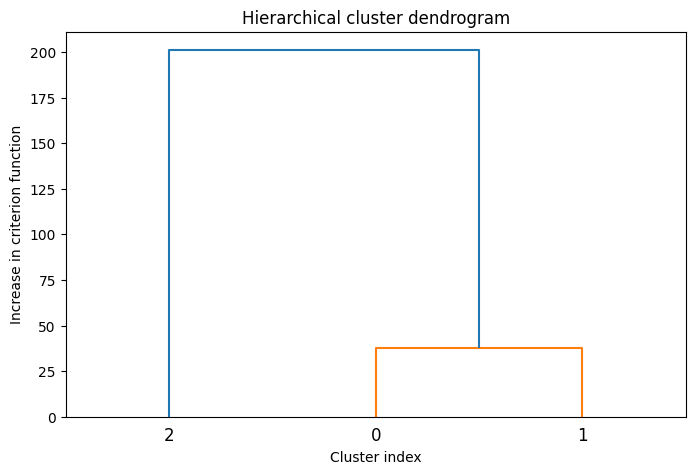

.
----------------------------------------------------------------------
Ran 1 test in 0.477s

OK


In [33]:
import unittest

import numpy as np
import scipy.linalg as la
import pylab as pl
import copy

import sheet2 as imp

class TestSheet2(unittest.TestCase):
    X = np.array([[0., 1., 1., 10., 10.25, 11., 10., 10.25, 11.],
                  [0., 0., 1.,  0.,   0.5,  0.,  5.,   5.5,  5.]]).T
    perfect_r = [1,0,1,2,2,1,2,2,2]

    def test_agglo(self):
        worked = False
        for _ in range(10):
            mu, r, _ = imp.kmeans(self.X, k=3)
            r = r.flatten()
            r_ = copy.deepcopy(r)
            R, kmloss, mergeidx = kmeans_agglo(self.X, r_)
            mergeidx = np.array(mergeidx, dtype=int)
            if set([int(r[3]), int(r[6])]) == set(mergeidx[0, :]):
                worked = True
                agglo_dendro(kmloss, mergeidx)
                break
        if not worked:
            raise AssertionError('test_agglo: the first merge is not correct.')

unittest.main(argv=[''], exit=False)